# Evaluate BEELINE network-sweep benchmark results

Computes precision / recall / F1 (plus AUPRC as a fully threshold-free metric) for every `rankedEdges.csv` produced by the BEELINE benchmark, against each dataset's `GroundTruthNetwork.csv`.

## Two threshold strategies -- computed and reported side by side

`rankedEdges.csv` is a *ranking*, not a binary prediction, so precision/recall/F1 need a cutoff. There isn't one universal cutoff that's fair to every algorithm, because algorithms differ in kind:

- **Top-k, tie-aware** -- for algorithms that output a genuine continuous ranking over the *full* edge space (e.g. correlation/MI scores for every possible pair). k = number of true edges in the ground truth (excluding self-loops); this mirrors BEELINE's own `EarlyPrecision` evaluator (`BLEval/EarlyPrecision.py`) exactly, including its tie-aware boundary (`best_val = max(smallest nonzero weight, weight of the k-th ranked edge)`, expanding to include all ties at that value rather than an arbitrary hard slice).
- **Natural / self-thresholded** -- for algorithms that internally make their own hard include/exclude decision and only assign a nonzero (or present) weight to edges they've decided are real (e.g. a significance test, or a fixed-size candidate-regulator list). Forcing these to the same top-k cutoff as the ground truth's edge count is unfair: a method that confidently outputs 6 edges when the true network has 17 shouldn't be penalized for not padding out to 17. This strategy just uses whatever the algorithm itself flagged as nonzero, with no truncation or padding.

Reporting both is also diagnostic: if an algorithm's two sets of numbers diverge a lot, that's a sign it's the "outputs its own fixed network" type rather than the "continuous ranking" type -- worth knowing regardless of which number you end up citing.

**AUPRC** (mirroring `BLEval/AUPRC.py`'s exact scoring-universe construction) is also computed as a fully threshold-free complementary metric.

In [1]:
import re
from itertools import combinations, permutations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import auc, precision_recall_curve

INPUT_ROOT = Path("/home/gzu5140/Keerthana_b1042/TwINFER/code/Beeline/inputs/network_sweep_final/cycle_6_node")
OUTPUT_ROOT = Path("/home/gzu5140/Keerthana_b1042/TwINFER/analysis_data/cycle_6_node/beeline_inference/cycle_6_node/")
RESULTS_CSV = OUTPUT_ROOT / "evaluation_metrics.csv"

# Matches e.g. "simrep04b768fb_spread" -> sim_rep="04b768fb", scheme="spread"
# (sim_rep is a hex hash here, not a plain integer)
RUN_ID_RE = re.compile(r"^simrep([0-9a-f]+)_(spread|twin_paired)$")

## Core evaluation logic

`build_edge_universe` and `top_k_tie_aware_selection` mirror `BLEval/EarlyPrecision.py`'s `_build_edge_universe`/`_compute_early_precision` exactly (directed non-self-loop gene pairs; `tf_edges=False`, appropriate for this synthetic data). `compute_auprc` mirrors `BLEval/AUPRC.py`'s `_compute_auprc` exactly. `natural_threshold_selection` is new -- there's no equivalent in `BLEval/`, since BEELINE itself only ever evaluates at the top-k cutoff.

In [2]:
def load_ground_truth(dataset_id: str) -> pd.DataFrame:
    # cycle_6_node uses one fixed topology for the whole sweep, so
    # GroundTruthNetwork.csv lives once directly under INPUT_ROOT rather than
    # being duplicated per dataset_id -- fall back to that shared copy.
    gt_path = INPUT_ROOT / dataset_id / "GroundTruthNetwork.csv"
    if not gt_path.exists():
        gt_path = INPUT_ROOT / "GroundTruthNetwork.csv"
    return pd.read_csv(gt_path, header=0)


def build_edge_universe(gt_df: pd.DataFrame):
    """All directed non-self-loop gene pairs among GT genes, and the true-edge subset."""
    gt_no_self = gt_df[gt_df["Gene1"] != gt_df["Gene2"]].drop_duplicates()
    unique_nodes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_edges = set(permutations(unique_nodes, 2))
    true_edges = set(zip(gt_no_self["Gene1"], gt_no_self["Gene2"])) & possible_edges
    return possible_edges, true_edges

def dedupe_predictions(ranked_edges: pd.DataFrame) -> pd.DataFrame:
    """Drop self-loops; keep the highest |EdgeWeight| per (Gene1, Gene2)."""
    pred = ranked_edges[ranked_edges["Gene1"] != ranked_edges["Gene2"]].copy()
    pred["_abs"] = pred["EdgeWeight"].abs()
    return (
        pred.sort_values("_abs", ascending=False)
        .drop_duplicates(subset=["Gene1", "Gene2"])
        .reset_index(drop=True)
    )


def top_k_tie_aware_selection(predicted: pd.DataFrame, num_true_edges: int):
    """
    Select the top-k predictions (k = num_true_edges), expanded to include all
    ties at the boundary weight -- same logic as
    BLEval.EarlyPrecision._compute_early_precision. Returns (selected_edge_set,
    threshold_weight_used).
    """
    if predicted.empty or num_true_edges == 0:
        return set(), float("nan")

    maxk = min(len(predicted), num_true_edges)
    edge_weight_topk = float(predicted.iloc[maxk - 1]["_abs"])

    nonzero = predicted.loc[predicted["_abs"] > 0, "_abs"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0

    best_val = max(non_zero_min, edge_weight_topk)
    selected = predicted[predicted["_abs"] >= best_val]
    return set(zip(selected["Gene1"], selected["Gene2"])), best_val


def natural_threshold_selection(predicted: pd.DataFrame):
    """
    Use whatever edges the algorithm itself assigned a nonzero weight to --
    no truncation or padding to match the ground truth's edge count. Fair to
    algorithms that make their own hard include/exclude decision (e.g. a
    significance test, or a fixed-size candidate-regulator list) rather than
    emitting a full continuous ranking meant to be externally truncated.
    """
    if predicted.empty:
        return set()
    selected = predicted[predicted["_abs"] > 0]
    return set(zip(selected["Gene1"], selected["Gene2"]))


def precision_recall_f1(selected_edges: set, true_edges: set):
    if not selected_edges:
        return 0.0, 0.0, 0.0
    tp = len(selected_edges & true_edges)
    precision = tp / len(selected_edges)
    recall = tp / len(true_edges) if true_edges else float("nan")
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1


def compute_auprc(ranked_edges: pd.DataFrame, gt_df: pd.DataFrame) -> float:
    """Fully threshold-free complementary metric -- mirrors BLEval.AUPRC._compute_auprc exactly."""
    gt_genes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_edges = list(permutations(gt_genes, 2))
    true_edge_set = set(zip(gt_df["Gene1"], gt_df["Gene2"]))

    pred = dedupe_predictions(ranked_edges)
    pred_lookup = dict(zip(zip(pred["Gene1"], pred["Gene2"]), pred["_abs"].astype(float)))

    true_labels = [1 if e in true_edge_set else 0 for e in possible_edges]
    pred_scores = [pred_lookup.get(e, 0.0) for e in possible_edges]

    if sum(true_labels) == 0:
        return float("nan")

    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))

## Two additional comparison strictness levels: signed+directed, and undirected+unsigned

The metrics above (`build_edge_universe`, `top_k_tie_aware_selection`, etc.) are directed but **sign-blind** -- a predicted `A->B` counts as correct regardless of whether the ground truth's `Type` (`+`/`-`) matches. Two more strictness levels bracket that:

- **Signed + directed** (`*_signed`) -- the strictest: a predicted edge only counts as correct if it matches the ground truth's `(Gene1, Gene2, Type)` exactly. Any mismatch -- wrong direction, wrong sign, or both -- is incorrect, full stop. For `auprc_signed` specifically: a wrong-sign prediction is scored as an **explicit false positive**, not merely an unscored miss. The scoring universe is every directed pair x both signs; a prediction's magnitude is only credited to the sign-position it actually predicted, so predicting `(A,B)` with the wrong sign shows up as a confident wrong answer at that rank (hurting precision), while the true `(A,B,true_sign)` position gets zero credit (a guaranteed miss for that edge) -- both consequences of the mismatch are real, not free.
- **Undirected + unsigned** (`*_undirected`) -- the most lenient: only "is there *any* relationship between these two genes" is evaluated. `(A,B)` and `(B,A)` collapse into one position (`frozenset({A,B})`), scored by whichever direction the algorithm ranked higher; sign is ignored entirely.

`n_true_edges_signed` and `n_true_edges_undirected` are computed separately per dataset (not assumed equal to the original `n_true_edges`), since a ground truth with any mutual/bidirectional regulation collapses to fewer undirected edges than directed ones.

**Partially available for TwINFER's fold-in rows below**: `twinfer_analysis_output.csv` now carries all three AUPRC levels (`auprc`, `auprc_signed`, `auprc_undirected`), computed in `network_sweep_analysis.ipynb` directly from each result JSON's `ranked_edge_list` (which has `directional_correlation`'s sign as the predicted sign) against the signed ground-truth matrix -- the same scoring-universe conventions as `compute_auprc_signed`/`compute_auprc_undirected` above. The `precision_topk_signed`/`recall_topk_signed`/etc. threshold-based columns are still `NaN` for TwINFER, since the summary CSV only carries directed, sign-blind TP/FP/FN/precision/recall/f1 (plus a `wrong_sign_edge` *count*, not a full re-derivable breakdown) -- there's no per-edge prediction set left to threshold at top-k or "natural" for the signed/undirected cases.

In [3]:
def build_signed_edge_universe(gt_df: pd.DataFrame):
    """Directed non-self-loop (Gene1, Gene2, Type) true-edge triples."""
    gt_no_self = gt_df[gt_df["Gene1"] != gt_df["Gene2"]].drop_duplicates()
    true_signed_edges = set(zip(gt_no_self["Gene1"], gt_no_self["Gene2"], gt_no_self["Type"]))
    return true_signed_edges


def build_undirected_edge_universe(gt_df: pd.DataFrame):
    """All undirected non-self-loop gene pairs among GT genes (as frozensets), and the true subset."""
    gt_no_self = gt_df[gt_df["Gene1"] != gt_df["Gene2"]].drop_duplicates()
    unique_nodes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_pairs = {frozenset(p) for p in combinations(unique_nodes, 2)}
    true_pairs = {frozenset((g1, g2)) for g1, g2 in zip(gt_no_self["Gene1"], gt_no_self["Gene2"])}
    return possible_pairs, true_pairs


def add_predicted_sign(predicted: pd.DataFrame) -> pd.DataFrame:
    """Attach a '+'/'-' predicted sign column derived from EdgeWeight's sign."""
    pred = predicted.copy()
    pred["_sign"] = np.where(pred["EdgeWeight"] >= 0, "+", "-")
    return pred


def top_k_tie_aware_selection_signed(predicted_signed: pd.DataFrame, num_true_edges: int):
    """Same top-k tie-aware boundary logic as top_k_tie_aware_selection, but selects and
    returns (Gene1, Gene2, predicted_sign) triples instead of (Gene1, Gene2) pairs."""
    if predicted_signed.empty or num_true_edges == 0:
        return set(), float("nan")
    maxk = min(len(predicted_signed), num_true_edges)
    edge_weight_topk = float(predicted_signed.iloc[maxk - 1]["_abs"])
    nonzero = predicted_signed.loc[predicted_signed["_abs"] > 0, "_abs"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0
    best_val = max(non_zero_min, edge_weight_topk)
    selected = predicted_signed[predicted_signed["_abs"] >= best_val]
    return set(zip(selected["Gene1"], selected["Gene2"], selected["_sign"])), best_val


def natural_threshold_selection_signed(predicted_signed: pd.DataFrame):
    if predicted_signed.empty:
        return set()
    selected = predicted_signed[predicted_signed["_abs"] > 0]
    return set(zip(selected["Gene1"], selected["Gene2"], selected["_sign"]))


def compute_auprc_signed(ranked_edges: pd.DataFrame, gt_df: pd.DataFrame) -> float:
    """
    AUPRC over directed AND signed edges. Scoring universe is every directed pair x both
    signs, so a wrong-signed prediction is scored as an explicit false positive (full
    magnitude credited to the *wrong* sign-position) rather than merely withheld -- see the
    markdown cell above for why.
    """
    gt_genes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_edges = list(permutations(gt_genes, 2))
    possible_signed_positions = [(g1, g2, s) for (g1, g2) in possible_edges for s in ("+", "-")]

    true_signed_edges = build_signed_edge_universe(gt_df)

    pred = dedupe_predictions(ranked_edges)
    pred = add_predicted_sign(pred)
    pred_score_by_pair = dict(zip(zip(pred["Gene1"], pred["Gene2"]), pred["_abs"].astype(float)))
    pred_sign_by_pair = dict(zip(zip(pred["Gene1"], pred["Gene2"]), pred["_sign"]))

    true_labels, pred_scores = [], []
    for (g1, g2, s) in possible_signed_positions:
        true_labels.append(1 if (g1, g2, s) in true_signed_edges else 0)
        predicted_sign_here = pred_sign_by_pair.get((g1, g2))
        score = pred_score_by_pair.get((g1, g2), 0.0) if predicted_sign_here == s else 0.0
        pred_scores.append(score)

    if sum(true_labels) == 0:
        return float("nan")
    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))


def dedupe_predictions_undirected(ranked_edges: pd.DataFrame) -> pd.DataFrame:
    """Drop self-loops; collapse (Gene1,Gene2) and (Gene2,Gene1) into one undirected edge
    (frozenset pair), keeping the highest |EdgeWeight| between the two directions."""
    pred = ranked_edges[ranked_edges["Gene1"] != ranked_edges["Gene2"]].copy()
    pred["_abs"] = pred["EdgeWeight"].abs()
    pred["_pair"] = [frozenset(p) for p in zip(pred["Gene1"], pred["Gene2"])]
    return (
        pred.sort_values("_abs", ascending=False)
        .drop_duplicates(subset=["_pair"])
        .reset_index(drop=True)
    )


def top_k_tie_aware_selection_undirected(predicted_undirected: pd.DataFrame, num_true_edges: int):
    if predicted_undirected.empty or num_true_edges == 0:
        return set(), float("nan")
    maxk = min(len(predicted_undirected), num_true_edges)
    edge_weight_topk = float(predicted_undirected.iloc[maxk - 1]["_abs"])
    nonzero = predicted_undirected.loc[predicted_undirected["_abs"] > 0, "_abs"]
    non_zero_min = float(nonzero.min()) if not nonzero.empty else 0.0
    best_val = max(non_zero_min, edge_weight_topk)
    selected = predicted_undirected[predicted_undirected["_abs"] >= best_val]
    return set(selected["_pair"]), best_val


def natural_threshold_selection_undirected(predicted_undirected: pd.DataFrame):
    if predicted_undirected.empty:
        return set()
    selected = predicted_undirected[predicted_undirected["_abs"] > 0]
    return set(selected["_pair"])


def compute_auprc_undirected(ranked_edges: pd.DataFrame, gt_df: pd.DataFrame) -> float:
    """AUPRC over undirected, unsigned edges -- only presence of a relationship is scored."""
    gt_genes = sorted(set(gt_df["Gene1"]).union(set(gt_df["Gene2"])))
    possible_pairs = [frozenset(p) for p in combinations(gt_genes, 2)]
    true_pairs = {frozenset((g1, g2)) for g1, g2 in zip(gt_df["Gene1"], gt_df["Gene2"])}

    pred = dedupe_predictions_undirected(ranked_edges)
    pred_lookup = dict(zip(pred["_pair"], pred["_abs"].astype(float)))

    true_labels = [1 if p in true_pairs else 0 for p in possible_pairs]
    pred_scores = [pred_lookup.get(p, 0.0) for p in possible_pairs]

    if sum(true_labels) == 0:
        return float("nan")
    precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
    return float(auc(recall, precision))

## Discover and evaluate every rankedEdges.csv

In [4]:
# --- OLD: assumed a 3-level dataset_dir/run_dir/algo_dir layout (matches
# network_sweep_final's per-topology structure). Doesn't match cycle_6_node,
# where OUTPUT_ROOT's direct children already are the run dirs -- kept here,
# commented out, for reference. ---
#
# rows = []
#
# for dataset_dir in sorted(OUTPUT_ROOT.iterdir()):
#     if not dataset_dir.is_dir():
#         continue
#     dataset_id = dataset_dir.name
#
#     gt_path = INPUT_ROOT / dataset_id / "GroundTruthNetwork.csv"
#     if not gt_path.exists():
#         # Skips non-dataset directories under OUTPUT_ROOT, e.g. the sbatch
#         # script's "logs/" dir for SLURM stdout/stderr.
#         continue
#
#     gt_df = load_ground_truth(dataset_id)
#     possible_edges, true_edges = build_edge_universe(gt_df)
#     num_true_edges = len(true_edges)
#     random_precision = num_true_edges / len(possible_edges) if possible_edges else float("nan")
#
#     true_signed_edges = build_signed_edge_universe(gt_df)
#     num_true_edges_signed = len(true_signed_edges)
#     # signed universe is directed pairs x 2 signs -- see compute_auprc_signed
#     random_precision_signed = num_true_edges_signed / (len(possible_edges) * 2) if possible_edges else float("nan")
#
#     possible_pairs_undirected, true_pairs_undirected = build_undirected_edge_universe(gt_df)
#     num_true_edges_undirected = len(true_pairs_undirected)
#     random_precision_undirected = (
#         num_true_edges_undirected / len(possible_pairs_undirected) if possible_pairs_undirected else float("nan")
#     )
#
#     for run_dir in sorted(dataset_dir.iterdir()):
#         if not run_dir.is_dir():
#             continue
#         run_id = run_dir.name
#         m = RUN_ID_RE.match(run_id)
#         sim_rep, scheme = (m.group(1), m.group(2)) if m else (None, None)
#
#         for algo_dir in sorted(run_dir.iterdir()):
#             ranked_path = algo_dir / "rankedEdges.csv"
#             if not ranked_path.exists():
#                 continue
#             algorithm = algo_dir.name
#
#             ranked_edges = pd.read_csv(ranked_path, sep="\t", header=0)
#             predicted = dedupe_predictions(ranked_edges)
#
#             selected_topk, threshold = top_k_tie_aware_selection(predicted, num_true_edges)
#             p_topk, r_topk, f1_topk = precision_recall_f1(selected_topk, true_edges)
#             epr = (p_topk / random_precision) if random_precision else float("nan")
#
#             selected_nat = natural_threshold_selection(predicted)
#             p_nat, r_nat, f1_nat = precision_recall_f1(selected_nat, true_edges)
#
#             auprc = compute_auprc(ranked_edges, gt_df)
#
#             # --- signed + directed: any mismatch (wrong direction or wrong sign) is incorrect ---
#             predicted_signed = add_predicted_sign(predicted)
#
#             selected_topk_signed, threshold_signed = top_k_tie_aware_selection_signed(
#                 predicted_signed, num_true_edges_signed
#             )
#             p_topk_s, r_topk_s, f1_topk_s = precision_recall_f1(selected_topk_signed, true_signed_edges)
#             epr_signed = (p_topk_s / random_precision_signed) if random_precision_signed else float("nan")
#
#             selected_nat_signed = natural_threshold_selection_signed(predicted_signed)
#             p_nat_s, r_nat_s, f1_nat_s = precision_recall_f1(selected_nat_signed, true_signed_edges)
#
#             auprc_signed = compute_auprc_signed(ranked_edges, gt_df)
#
#             # --- undirected + unsigned: only presence of a relationship is considered ---
#             predicted_undirected = dedupe_predictions_undirected(ranked_edges)
#
#             selected_topk_und, threshold_und = top_k_tie_aware_selection_undirected(
#                 predicted_undirected, num_true_edges_undirected
#             )
#             p_topk_u, r_topk_u, f1_topk_u = precision_recall_f1(selected_topk_und, true_pairs_undirected)
#             epr_undirected = (p_topk_u / random_precision_undirected) if random_precision_undirected else float("nan")
#
#             selected_nat_und = natural_threshold_selection_undirected(predicted_undirected)
#             p_nat_u, r_nat_u, f1_nat_u = precision_recall_f1(selected_nat_und, true_pairs_undirected)
#
#             auprc_undirected = compute_auprc_undirected(ranked_edges, gt_df)
#
#             rows.append({
#                 "dataset_id": dataset_id,
#                 "run_id": run_id,
#                 "sim_rep": sim_rep,
#                 "scheme": scheme,
#                 "algorithm": algorithm,
#                 "n_true_edges": num_true_edges,
#                 # top-k, tie-aware (BEELINE EPR convention)
#                 "n_selected_topk": len(selected_topk),
#                 "threshold_weight_topk": threshold,
#                 "precision_topk": p_topk,
#                 "recall_topk": r_topk,
#                 "f1_topk": f1_topk,
#                 "epr_topk": epr,
#                 # natural / self-thresholded (algorithm's own nonzero edges)
#                 "n_selected_natural": len(selected_nat),
#                 "precision_natural": p_nat,
#                 "recall_natural": r_nat,
#                 "f1_natural": f1_nat,
#                 # fully threshold-free
#                 "auprc": auprc,
#                 # signed + directed: any mismatch is incorrect
#                 "n_true_edges_signed": num_true_edges_signed,
#                 "n_selected_topk_signed": len(selected_topk_signed),
#                 "threshold_weight_topk_signed": threshold_signed,
#                 "precision_topk_signed": p_topk_s,
#                 "recall_topk_signed": r_topk_s,
#                 "f1_topk_signed": f1_topk_s,
#                 "epr_topk_signed": epr_signed,
#                 "n_selected_natural_signed": len(selected_nat_signed),
#                 "precision_natural_signed": p_nat_s,
#                 "recall_natural_signed": r_nat_s,
#                 "f1_natural_signed": f1_nat_s,
#                 "auprc_signed": auprc_signed,
#                 # undirected + unsigned: only presence of an edge is considered
#                 "n_true_edges_undirected": num_true_edges_undirected,
#                 "n_selected_topk_undirected": len(selected_topk_und),
#                 "threshold_weight_topk_undirected": threshold_und,
#                 "precision_topk_undirected": p_topk_u,
#                 "recall_topk_undirected": r_topk_u,
#                 "f1_topk_undirected": f1_topk_u,
#                 "epr_topk_undirected": epr_undirected,
#                 "n_selected_natural_undirected": len(selected_nat_und),
#                 "precision_natural_undirected": p_nat_u,
#                 "recall_natural_undirected": r_nat_u,
#                 "f1_natural_undirected": f1_nat_u,
#                 "auprc_undirected": auprc_undirected,
#             })
#
# results = pd.DataFrame(rows)
# results.to_csv(RESULTS_CSV, index=False)
# print(f"Evaluated {len(results)} (dataset, run, algorithm) combinations.")
# print(f"Saved to {RESULTS_CSV}")
# results.head()


# --- NEW: cycle_6_node uses one fixed topology for the whole sweep, so there's
# no per-topology grouping layer -- OUTPUT_ROOT's direct children are already
# the individual (sim_rep, scheme) run dirs, each holding one subdir per
# algorithm with rankedEdges.csv directly inside. ---

rows = []

dataset_id = "cycle_6_node"

gt_df = load_ground_truth(dataset_id)
possible_edges, true_edges = build_edge_universe(gt_df)
num_true_edges = len(true_edges)
random_precision = num_true_edges / len(possible_edges) if possible_edges else float("nan")

true_signed_edges = build_signed_edge_universe(gt_df)
num_true_edges_signed = len(true_signed_edges)
# signed universe is directed pairs x 2 signs -- see compute_auprc_signed
random_precision_signed = num_true_edges_signed / (len(possible_edges) * 2) if possible_edges else float("nan")

possible_pairs_undirected, true_pairs_undirected = build_undirected_edge_universe(gt_df)
num_true_edges_undirected = len(true_pairs_undirected)
random_precision_undirected = (
    num_true_edges_undirected / len(possible_pairs_undirected) if possible_pairs_undirected else float("nan")
)

for run_dir in sorted(OUTPUT_ROOT.iterdir()):
    if not run_dir.is_dir():
        continue
    run_id = run_dir.name
    m = RUN_ID_RE.match(run_id)
    if not m:
        # Skips non-run directories under OUTPUT_ROOT, e.g. the sbatch
        # script's "logs/" dir for SLURM stdout/stderr.
        continue
    sim_rep, scheme = m.group(1), m.group(2)

    for algo_dir in sorted(run_dir.iterdir()):
        ranked_path = algo_dir / "rankedEdges.csv"
        if not ranked_path.exists():
            continue
        algorithm = algo_dir.name

        ranked_edges = pd.read_csv(ranked_path, sep="\t", header=0)
        predicted = dedupe_predictions(ranked_edges)

        selected_topk, threshold = top_k_tie_aware_selection(predicted, num_true_edges)
        p_topk, r_topk, f1_topk = precision_recall_f1(selected_topk, true_edges)
        epr = (p_topk / random_precision) if random_precision else float("nan")

        selected_nat = natural_threshold_selection(predicted)
        p_nat, r_nat, f1_nat = precision_recall_f1(selected_nat, true_edges)

        auprc = compute_auprc(ranked_edges, gt_df)

        # --- signed + directed: any mismatch (wrong direction or wrong sign) is incorrect ---
        predicted_signed = add_predicted_sign(predicted)

        selected_topk_signed, threshold_signed = top_k_tie_aware_selection_signed(
            predicted_signed, num_true_edges_signed
        )
        p_topk_s, r_topk_s, f1_topk_s = precision_recall_f1(selected_topk_signed, true_signed_edges)
        epr_signed = (p_topk_s / random_precision_signed) if random_precision_signed else float("nan")

        selected_nat_signed = natural_threshold_selection_signed(predicted_signed)
        p_nat_s, r_nat_s, f1_nat_s = precision_recall_f1(selected_nat_signed, true_signed_edges)

        auprc_signed = compute_auprc_signed(ranked_edges, gt_df)

        # --- undirected + unsigned: only presence of a relationship is considered ---
        predicted_undirected = dedupe_predictions_undirected(ranked_edges)

        selected_topk_und, threshold_und = top_k_tie_aware_selection_undirected(
            predicted_undirected, num_true_edges_undirected
        )
        p_topk_u, r_topk_u, f1_topk_u = precision_recall_f1(selected_topk_und, true_pairs_undirected)
        epr_undirected = (p_topk_u / random_precision_undirected) if random_precision_undirected else float("nan")

        selected_nat_und = natural_threshold_selection_undirected(predicted_undirected)
        p_nat_u, r_nat_u, f1_nat_u = precision_recall_f1(selected_nat_und, true_pairs_undirected)

        auprc_undirected = compute_auprc_undirected(ranked_edges, gt_df)

        rows.append({
            "dataset_id": dataset_id,
            "run_id": run_id,
            "sim_rep": sim_rep,
            "scheme": scheme,
            "algorithm": algorithm,
            "n_true_edges": num_true_edges,
            # top-k, tie-aware (BEELINE EPR convention)
            "n_selected_topk": len(selected_topk),
            "threshold_weight_topk": threshold,
            "precision_topk": p_topk,
            "recall_topk": r_topk,
            "f1_topk": f1_topk,
            "epr_topk": epr,
            # natural / self-thresholded (algorithm's own nonzero edges)
            "n_selected_natural": len(selected_nat),
            "precision_natural": p_nat,
            "recall_natural": r_nat,
            "f1_natural": f1_nat,
            # fully threshold-free
            "auprc": auprc,
            # signed + directed: any mismatch is incorrect
            "n_true_edges_signed": num_true_edges_signed,
            "n_selected_topk_signed": len(selected_topk_signed),
            "threshold_weight_topk_signed": threshold_signed,
            "precision_topk_signed": p_topk_s,
            "recall_topk_signed": r_topk_s,
            "f1_topk_signed": f1_topk_s,
            "epr_topk_signed": epr_signed,
            "n_selected_natural_signed": len(selected_nat_signed),
            "precision_natural_signed": p_nat_s,
            "recall_natural_signed": r_nat_s,
            "f1_natural_signed": f1_nat_s,
            "auprc_signed": auprc_signed,
            # undirected + unsigned: only presence of an edge is considered
            "n_true_edges_undirected": num_true_edges_undirected,
            "n_selected_topk_undirected": len(selected_topk_und),
            "threshold_weight_topk_undirected": threshold_und,
            "precision_topk_undirected": p_topk_u,
            "recall_topk_undirected": r_topk_u,
            "f1_topk_undirected": f1_topk_u,
            "epr_topk_undirected": epr_undirected,
            "n_selected_natural_undirected": len(selected_nat_und),
            "precision_natural_undirected": p_nat_u,
            "recall_natural_undirected": r_nat_u,
            "f1_natural_undirected": f1_nat_u,
            "auprc_undirected": auprc_undirected,
        })

results = pd.DataFrame(rows)
results.to_csv(RESULTS_CSV, index=False)
print(f"Evaluated {len(results)} (dataset, run, algorithm) combinations.")
print(f"Saved to {RESULTS_CSV}")
results.head()

Evaluated 123 (dataset, run, algorithm) combinations.
Saved to /home/gzu5140/Keerthana_b1042/TwINFER/analysis_data/cycle_6_node/beeline_inference/cycle_6_node/evaluation_metrics.csv


,dataset_id,run_id,sim_rep,scheme,algorithm,n_true_edges,n_selected_topk,threshold_weight_topk,precision_topk,recall_topk,...,threshold_weight_topk_undirected,precision_topk_undirected,recall_topk_undirected,f1_topk_undirected,epr_topk_undirected,n_selected_natural_undirected,precision_natural_undirected,recall_natural_undirected,f1_natural_undirected,auprc_undirected
0,cycle_6_node,simrep04b768fb_spread,04b768fb,spread,GRNBOOST2,6,6,8.039587,0.500000,0.500000,...,4.903460,0.833333,0.833333,0.833333,2.083333,15,0.4,1.000000,0.571429,0.955357
1,cycle_6_node,simrep04b768fb_spread,04b768fb,spread,PEARSON,6,6,0.034781,0.500000,0.500000,...,0.020935,1.000000,1.000000,1.000000,2.500000,15,0.4,1.000000,0.571429,1.000000
2,cycle_6_node,simrep04b768fb_spread,04b768fb,spread,PIDC,6,6,1.676809,0.500000,0.500000,...,1.239914,0.833333,0.833333,0.833333,2.083333,15,0.4,1.000000,0.571429,0.852399
3,cycle_6_node,simrep04b768fb_spread,04b768fb,spread,PPCOR,6,6,0.035844,0.500000,0.500000,...,0.026287,1.000000,0.833333,0.909091,2.500000,5,1.0,0.833333,0.909091,0.950000
4,cycle_6_node,simrep04b768fb_spread,04b768fb,spread,SCODE,6,6,115.822280,0.166667,0.166667,...,114.919172,0.333333,0.333333,0.333333,0.833333,15,0.4,1.000000,0.571429,0.437950


## Fold in TwINFER's own inference results

`twinfer_analysis_output.csv` (built by `network_sweep_analysis.ipynb`'s `score_sweep_folder`) already has TP/FP/FN/TN/precision/recall/f1 computed per (topology, sim_rep) using TwINFER's own edge-classification methodology, plus all three AUPRC levels (`auprc`, `auprc_signed`, `auprc_undirected`), computed there from each result JSON's `ranked_edge_list` against the signed ground-truth matrix -- fully threshold-free, just like the BEELINE algorithms' AUPRC columns above. Unlike the BEELINE algorithms, TwINFER makes a single hard decision per edge rather than emitting a ranked score, so there's no top-k-vs-natural distinction to make here -- both columns get the same value. The threshold-based `precision_topk_signed`/`recall_topk_signed`/etc. columns are still left as NaN, since the summary CSV only carries directed, sign-blind TP/FP/FN (see the strictness-levels markdown cell below for why those specifically can't be reconstructed from it).

In [5]:
TWINFER_CSV = Path("/home/gzu5140/Keerthana_b1042/TwINFER/analysis_data/network_sweep_final/twinfer_analysis_cyclic.csv")
TWINFER_REP_RE = re.compile(r"rep(\d+)_rep(\d+)")

twinfer_df = pd.read_csv(TWINFER_CSV)
twinfer_rows = []

for _, row in twinfer_df.iterrows():
    dataset_id = row["matched_topology_file"].replace(".txt", "")
    m = TWINFER_REP_RE.search(row["json_file"])
    sim_rep = m.group(2) if m else None

    gt_df = load_ground_truth(dataset_id)
    possible_edges, _ = build_edge_universe(gt_df)

    # --- sign-blind (directed only) ---
    num_true_edges = int(row["TP"] + row["FN"])
    random_precision = num_true_edges / len(possible_edges) if possible_edges else float("nan")
    epr = (row["precision"] / random_precision) if random_precision else float("nan")
    n_selected = int(row["TP"] + row["FP"])

    # --- directed AND signed (strictest) ---
    num_true_edges_signed = int(row["TP_signed"] + row["FN_signed"])
    # signed universe is directed pairs x 2 signs -- matches
    # random_precision_signed's convention in the discovery-loop cell above
    random_precision_signed = (
        num_true_edges_signed / (len(possible_edges) * 2) if possible_edges else float("nan")
    )
    epr_signed = (row["precision_signed"] / random_precision_signed) if random_precision_signed else float("nan")
    n_selected_signed = int(row["TP_signed"] + row["FP_signed"])

    twinfer_rows.append({
        "dataset_id": dataset_id,
        "run_id": f"simrep{sim_rep}_twinfer",
        "sim_rep": sim_rep,
        "scheme": "twinfer",
        "algorithm": "TwINFER",
        "n_true_edges": num_true_edges,
        "n_selected_topk": n_selected,
        "threshold_weight_topk": float("nan"),
        "precision_topk": row["precision"],
        "recall_topk": row["recall"],
        "f1_topk": row["f1"],
        "epr_topk": epr,
        "n_selected_natural": n_selected,
        "precision_natural": row["precision"],
        "recall_natural": row["recall"],
        "f1_natural": row["f1"],
        # All three AUPRC levels, computed in network_sweep_analysis.ipynb's
        # score_sweep_folder from each result JSON's ranked_edge_list (which
        # carries directional_correlation's sign as the predicted sign) against
        # the signed ground-truth matrix -- fully threshold-free, unlike the
        # precision/recall/f1 columns above. NaN for any row whose JSON predates
        # ranked_list=True.
        "auprc": row["auprc"],
        # Directed AND signed (strictest): TwINFER's own score_directed_edges
        # now computes TP_signed/FP_signed/FN_signed alongside the sign-blind
        # counts in the same pass, so these are real values (not NaN) --
        # TwINFER makes a single hard decision per edge rather than emitting a
        # ranked score, so there's no top-k-vs-natural distinction here either;
        # both columns get the same value, same as the sign-blind columns above.
        "n_true_edges_signed": num_true_edges_signed,
        "n_selected_topk_signed": n_selected_signed,
        "threshold_weight_topk_signed": float("nan"),
        "precision_topk_signed": row["precision_signed"],
        "recall_topk_signed": row["recall_signed"],
        "f1_topk_signed": row["f1_signed"],
        "epr_topk_signed": epr_signed,
        "n_selected_natural_signed": n_selected_signed,
        "precision_natural_signed": row["precision_signed"],
        "recall_natural_signed": row["recall_signed"],
        "f1_natural_signed": row["f1_signed"],
        "auprc_signed": row["auprc_signed"],
        # Undirected/unsigned TP/FP/FN/precision/recall/f1 aren't computed by
        # score_directed_edges at all (only the AUPRC-level undirected metric
        # has a TwINFER-side counterpart, via compute_twinfer_auprc_undirected),
        # so these threshold-based columns stay NaN -- see the markdown cell
        # above "Two additional comparison strictness levels".
        "n_true_edges_undirected": float("nan"),
        "n_selected_topk_undirected": float("nan"),
        "threshold_weight_topk_undirected": float("nan"),
        "precision_topk_undirected": float("nan"),
        "recall_topk_undirected": float("nan"),
        "f1_topk_undirected": float("nan"),
        "epr_topk_undirected": float("nan"),
        "n_selected_natural_undirected": float("nan"),
        "precision_natural_undirected": float("nan"),
        "recall_natural_undirected": float("nan"),
        "f1_natural_undirected": float("nan"),
        "auprc_undirected": row["auprc_undirected"],
    })

results = pd.concat([results, pd.DataFrame(twinfer_rows)], ignore_index=True)
results.to_csv(RESULTS_CSV, index=False)
print(f"Added {len(twinfer_rows)} TwINFER rows. results now has {len(results)} total rows.")

Added 10 TwINFER rows. results now has 133 total rows.


## Summary table: mean metrics per algorithm x scheme

Averaged across all datasets and simulation replicates. `n_selected_natural` close to `n_true_edges` on average means that algorithm's own natural output size happens to land near the ground truth's edge count -- worth checking before trusting the top-k numbers for it in isolation.

In [6]:
summary = (
    results.groupby(["algorithm", "scheme"])[[
        "precision_topk", "recall_topk", "f1_topk", "epr_topk",
        "precision_natural", "recall_natural", "f1_natural",
        "n_selected_natural", "n_true_edges", "auprc",
        "precision_topk_signed", "recall_topk_signed", "f1_topk_signed", "auprc_signed",
        "precision_topk_undirected", "recall_topk_undirected", "f1_topk_undirected", "auprc_undirected",
    ]]
    .mean()
    .round(3)
    .sort_values("f1_topk", ascending=False)
)
summary

precision_topk  recall_topk  f1_topk  epr_topk  \
algorithm scheme                                                        
TwINFER   twinfer               0.948        0.933    0.936     4.741   
GRNBOOST2 twin_paired           0.533        0.533    0.533     2.667   
PEARSON   spread                0.500        0.500    0.500     2.500   
PPCOR     spread                0.500        0.500    0.500     2.500   
          twin_paired           0.500        0.500    0.500     2.500   
PEARSON   twin_paired           0.500        0.500    0.500     2.500   
GRNBOOST2 spread                0.467        0.467    0.467     2.333   
PIDC      spread                0.400        0.400    0.400     2.000   
          twin_paired           0.350        0.350    0.350     1.750   
SCODE     spread                0.233        0.233    0.233     1.167   
          twin_paired           0.217        0.217    0.217     1.083   
SCSGL     spread                0.183        0.183    0.183     0.917   
          twin_paired           0.150        0.150    0.150     0.750   
GENIE3    spread                0.000        0.000    0.000     0.000   
          twin_paired           0.000        0.000    0.000     0.000   

                       precision_natural  recall_natural  f1_natural  \
algorithm scheme                                                       
TwINFER   twinfer                  0.948           0.933       0.936   
GRNBOOST2 twin_paired              0.200           1.000       0.333   
PEARSON   spread                   0.200           1.000       0.333   
PPCOR     spread                   0.492           0.933       0.643   
          twin_paired              0.492           0.917       0.638   
PEARSON   twin_paired              0.200           1.000       0.333   
GRNBOOST2 spread                   0.200           1.000       0.333   
PIDC      spread                   0.200           1.000       0.333   
          twin_paired              0.200           1.000       0.333   
SCODE     spread                   0.200           1.000       0.333   
          twin_paired              0.200           1.000       0.333   
SCSGL     spread                   0.207           0.983       0.342   
          twin_paired              0.220           0.983       0.359   
GENIE3    spread                   0.200           1.000       0.333   
          twin_paired              0.200           1.000       0.333   

                       n_selected_natural  n_true_edges  auprc  \
algorithm scheme                                                 
TwINFER   twinfer                     6.0           6.0  0.993   
GRNBOOST2 twin_paired                30.0           6.0  0.558   
PEARSON   spread                     30.0           6.0  0.536   
PPCOR     spread                     11.4           6.0  0.516   
          twin_paired                11.2           6.0  0.529   
PEARSON   twin_paired                30.0           6.0  0.533   
GRNBOOST2 spread                     30.0           6.0  0.507   
PIDC      spread                     30.0           6.0  0.424   
          twin_paired                30.0           6.0  0.369   
SCODE     spread                     30.0           6.0  0.237   
          twin_paired                30.0           6.0  0.247   
SCSGL     spread                     28.6           6.0  0.267   
          twin_paired                27.0           6.0  0.255   
GENIE3    spread                     30.0           6.0  0.131   
          twin_paired                30.0           6.0  0.118   

                       precision_topk_signed  recall_topk_signed  \
algorithm scheme                                                   
TwINFER   twinfer                      0.948               0.933   
GRNBOOST2 twin_paired                  0.533               0.533   
PEARSON   spread                       0.500               0.500   
PPCOR     spread                       0.500               0.500   
          twin_paired    

## Plots

Grouped bar chart: algorithm identity is already encoded by x-axis position, so color is reserved for the one thing that actually needs it here -- the sampling scheme (`spread` vs `twin_paired`), using the first two slots of the validated categorical palette in fixed order.

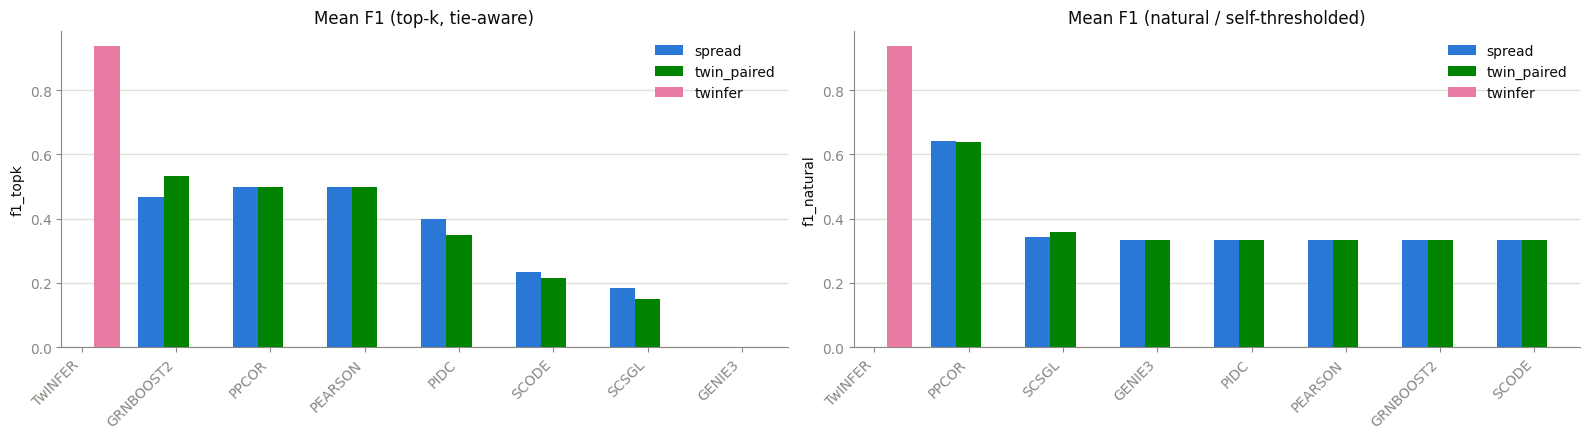

In [7]:
# Validated categorical palette (references/palette.md), fixed order, light-mode steps
SCHEME_COLORS = {"spread": "#2a78d6", "twin_paired": "#008300", "twinfer": "#e87ba4"}
SCHEME_ORDER = ["spread", "twin_paired", "twinfer"]
INK_PRIMARY = "#0b0b0b"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"


def plot_metric_by_algorithm(metric: str, ax=None, title=None):
    pivot = results.groupby(["algorithm", "scheme"])[metric].mean().unstack("scheme")
    pivot = pivot.reindex(columns=[c for c in SCHEME_ORDER if c in pivot.columns])
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(9, 4.5))

    x = range(len(pivot))
    width = 0.8 / max(len(pivot.columns), 1)
    for i, scheme in enumerate(pivot.columns):
        offsets = [xi + (i - (len(pivot.columns) - 1) / 2) * width for xi in x]
        ax.bar(offsets, pivot[scheme], width=width, color=SCHEME_COLORS.get(scheme, INK_MUTED),
               label=scheme, zorder=3)

    ax.set_xticks(list(x))
    ax.set_xticklabels(pivot.index, rotation=45, ha="right", color=INK_PRIMARY)
    ax.set_ylabel(metric, color=INK_PRIMARY)
    ax.set_title(title or f"Mean {metric} by algorithm", color=INK_PRIMARY)
    ax.grid(axis="y", color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(INK_MUTED)
    ax.tick_params(colors=INK_MUTED)
    # Older matplotlib (3.0.x, installed in the BEELINE env) doesn't support
    # legend(labelcolor=...) -- added in 3.3. Set text color on the returned
    # Legend's text objects directly instead, which works on any version.
    legend = ax.legend(frameon=False)
    for text in legend.get_texts():
        text.set_color(INK_PRIMARY)

    if own_ax:
        fig.tight_layout()
        return fig


fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
plot_metric_by_algorithm("f1_topk", ax=axes[0], title="Mean F1 (top-k, tie-aware)")
plot_metric_by_algorithm("f1_natural", ax=axes[1], title="Mean F1 (natural / self-thresholded)")
fig.tight_layout()

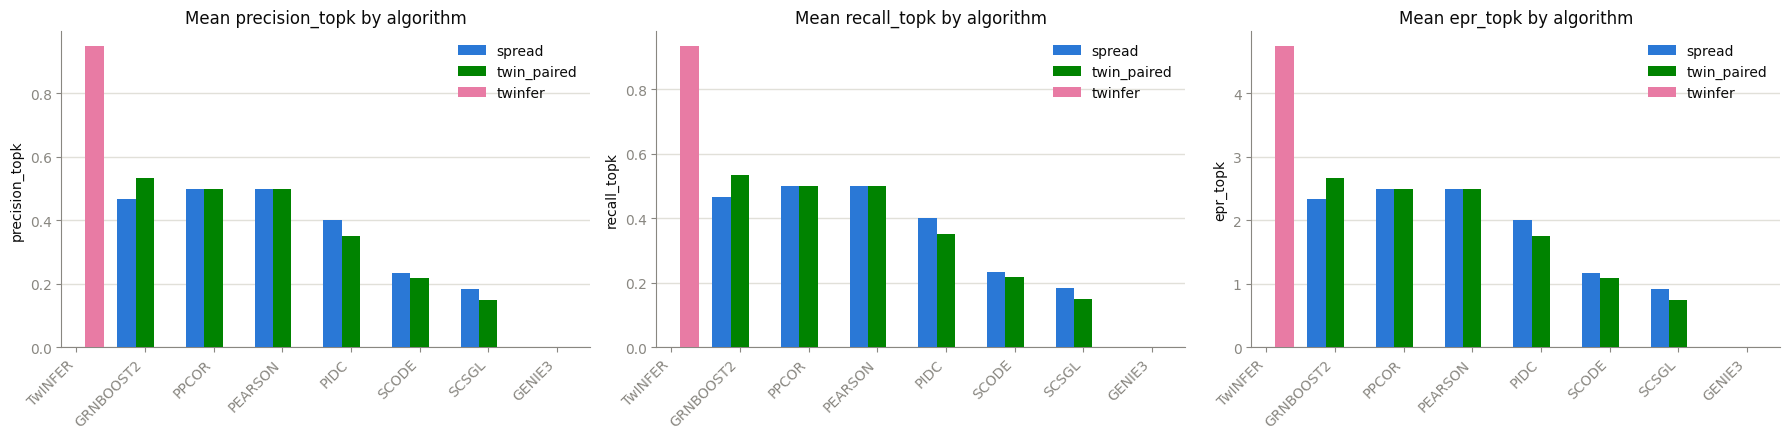

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
plot_metric_by_algorithm("precision_topk", ax=axes[0])
plot_metric_by_algorithm("recall_topk", ax=axes[1])
plot_metric_by_algorithm("epr_topk", ax=axes[2])
fig.tight_layout()

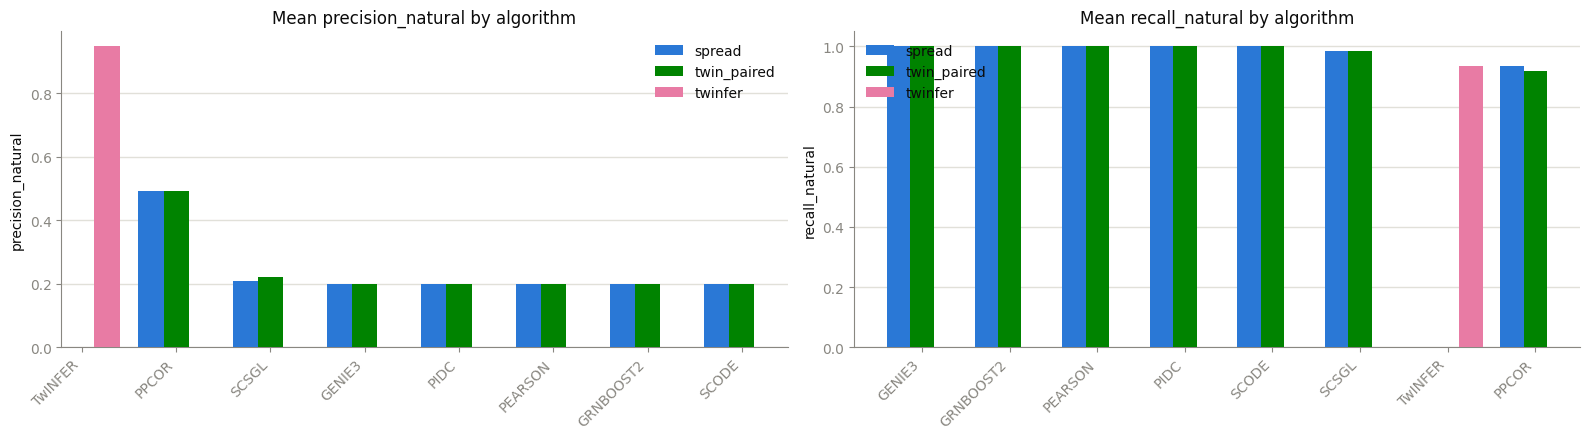

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
plot_metric_by_algorithm("precision_natural", ax=axes[0])
plot_metric_by_algorithm("recall_natural", ax=axes[1])
fig.tight_layout()

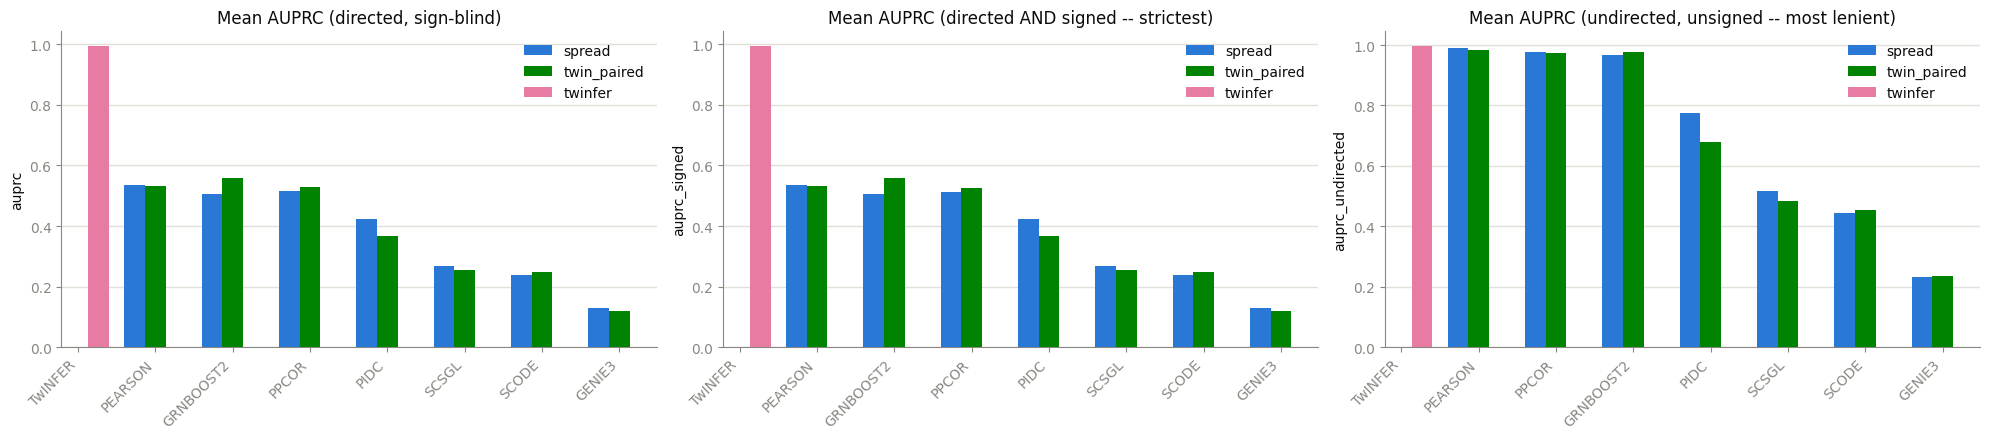

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
plot_metric_by_algorithm("auprc", ax=axes[0], title="Mean AUPRC (directed, sign-blind)")
plot_metric_by_algorithm("auprc_signed", ax=axes[1], title="Mean AUPRC (directed AND signed -- strictest)")
plot_metric_by_algorithm("auprc_undirected", ax=axes[2], title="Mean AUPRC (undirected, unsigned -- most lenient)")
fig.tight_layout()

## Distribution per individual dataset

One box (quartile spread across every algorithm x scheme x sim_rep combination evaluated on that dataset) plus jittered individual points per dataset, colored by scheme so the same categorical mapping used above still applies. This shows how much a metric varies *within* a single topology, not just its mean across topologies.

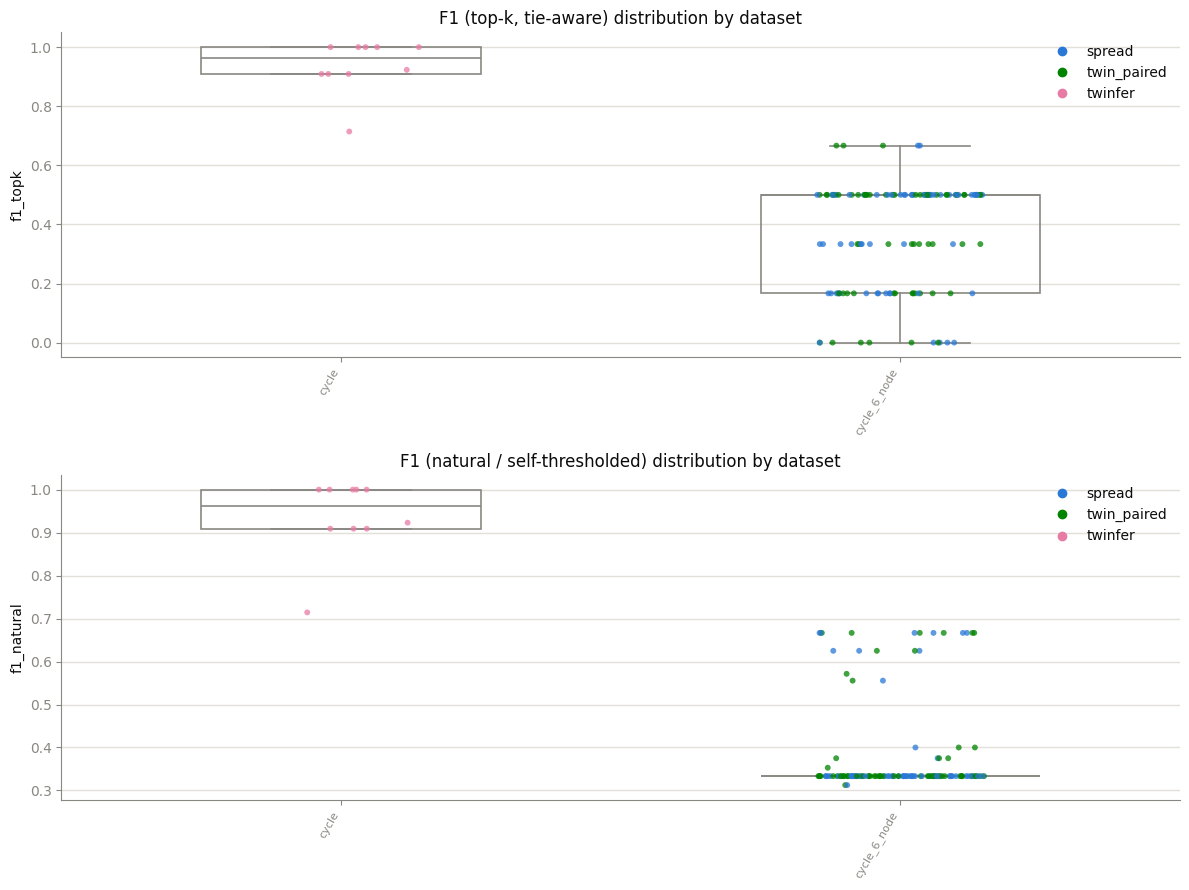

In [11]:
import numpy as np

# np.random.default_rng needs numpy>=1.17; this env pins numpy 1.15.4, so use
# the legacy RandomState API instead.
_rng = np.random.RandomState(0)


def plot_box_dot_by_dataset(metric: str, ax=None, title=None):
    dataset_ids = sorted(results["dataset_id"].unique())
    grouped = [
        results.loc[results["dataset_id"] == d, metric].dropna().values
        for d in dataset_ids
    ]

    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(12, 5))

    positions = range(1, len(dataset_ids) + 1)
    bp = ax.boxplot(
        grouped, positions=list(positions), widths=0.5, showfliers=False,
        patch_artist=True,
    )
    for box in bp["boxes"]:
        box.set(facecolor="none", edgecolor=INK_MUTED, linewidth=1.2, zorder=2)
    for element in ["whiskers", "caps", "medians"]:
        for artist in bp[element]:
            artist.set(color=INK_MUTED, linewidth=1.2)

    # Jittered dots on top, colored by scheme (same mapping as the bar charts above)
    for pos, dataset_id in zip(positions, dataset_ids):
        subset = results[results["dataset_id"] == dataset_id].dropna(subset=[metric])
        jitter = _rng.uniform(-0.15, 0.15, size=len(subset))
        colors = subset["scheme"].map(SCHEME_COLORS).fillna(INK_MUTED)
        ax.scatter(
            pos + jitter, subset[metric],
            color=colors, s=18, alpha=0.75, zorder=3, linewidths=0,
        )

    ax.set_xticks(list(positions))
    ax.set_xticklabels(dataset_ids, rotation=60, ha="right", color=INK_PRIMARY, fontsize=8)
    ax.set_ylabel(metric, color=INK_PRIMARY)
    ax.set_title(title or f"{metric} distribution by dataset", color=INK_PRIMARY)
    ax.grid(axis="y", color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(INK_MUTED)
    ax.tick_params(colors=INK_MUTED)

    # Legend for scheme colors (dots aren't from ax.bar/scatter-with-label, so build handles manually)
    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", color=c, label=s)
        for s, c in SCHEME_COLORS.items()
        if s in results["scheme"].unique()
    ]
    legend = ax.legend(handles=handles, frameon=False, loc="upper right")
    for text in legend.get_texts():
        text.set_color(INK_PRIMARY)

    if own_ax:
        fig.tight_layout()
        return fig


fig, axes = plt.subplots(2, 1, figsize=(12, 9))
plot_box_dot_by_dataset("f1_topk", ax=axes[0], title="F1 (top-k, tie-aware) distribution by dataset")
plot_box_dot_by_dataset("f1_natural", ax=axes[1], title="F1 (natural / self-thresholded) distribution by dataset")
fig.tight_layout()

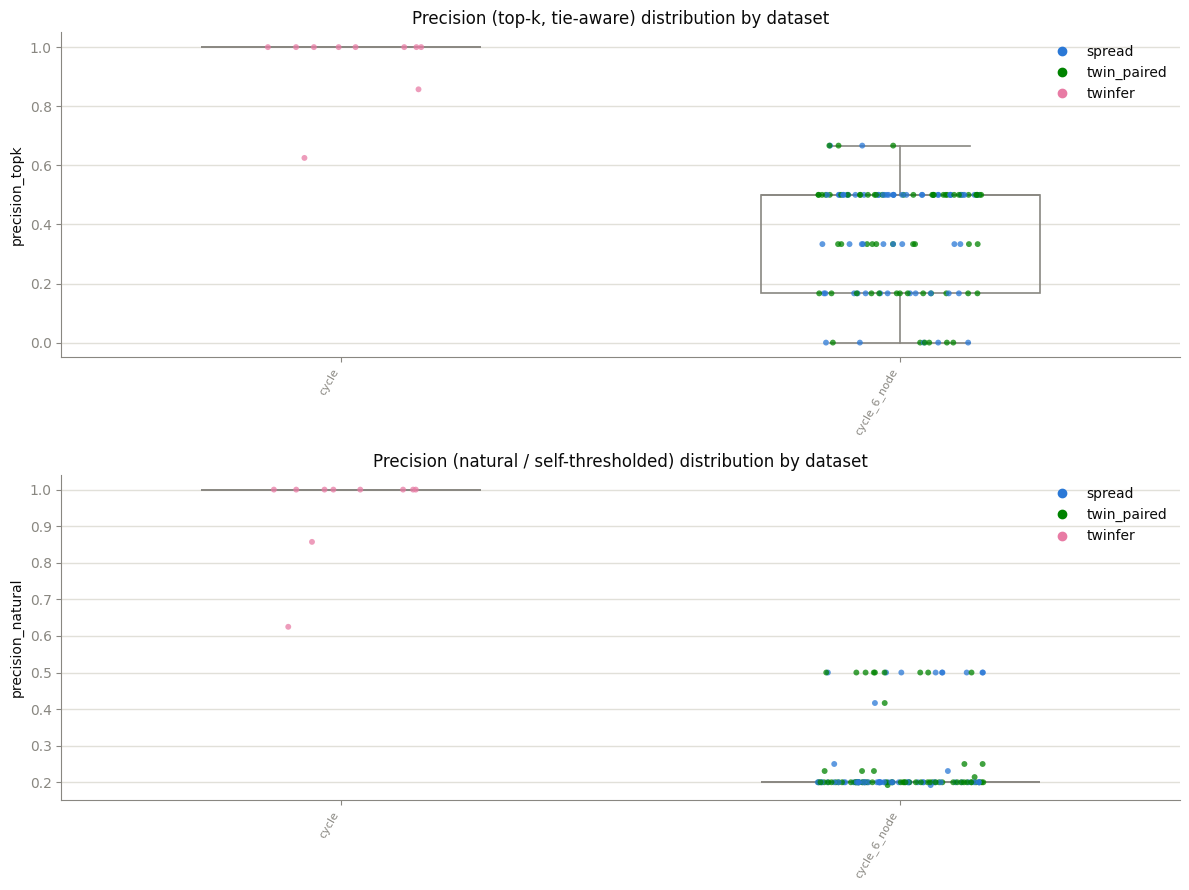

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
plot_box_dot_by_dataset("precision_topk", ax=axes[0], title="Precision (top-k, tie-aware) distribution by dataset")
plot_box_dot_by_dataset("precision_natural", ax=axes[1], title="Precision (natural / self-thresholded) distribution by dataset")
fig.tight_layout()

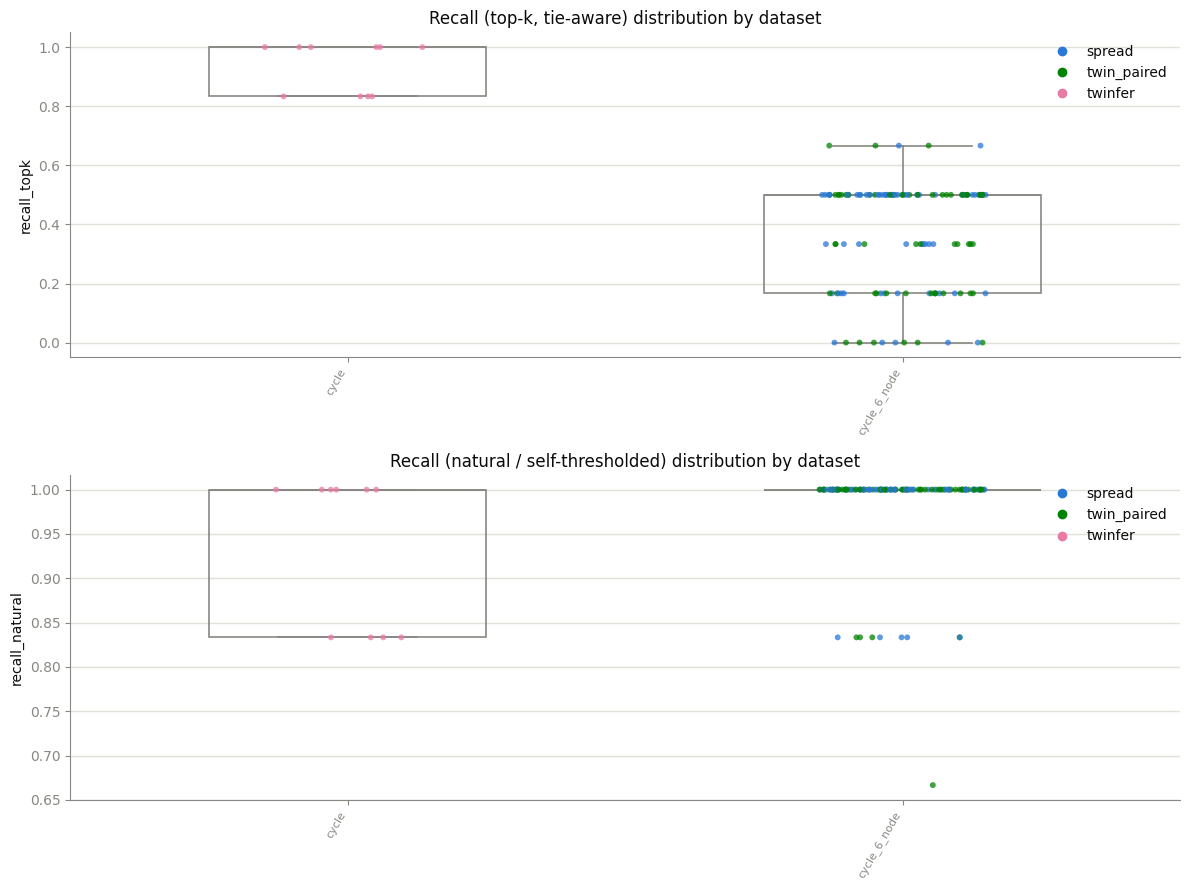

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
plot_box_dot_by_dataset("recall_topk", ax=axes[0], title="Recall (top-k, tie-aware) distribution by dataset")
plot_box_dot_by_dataset("recall_natural", ax=axes[1], title="Recall (natural / self-thresholded) distribution by dataset")
fig.tight_layout()

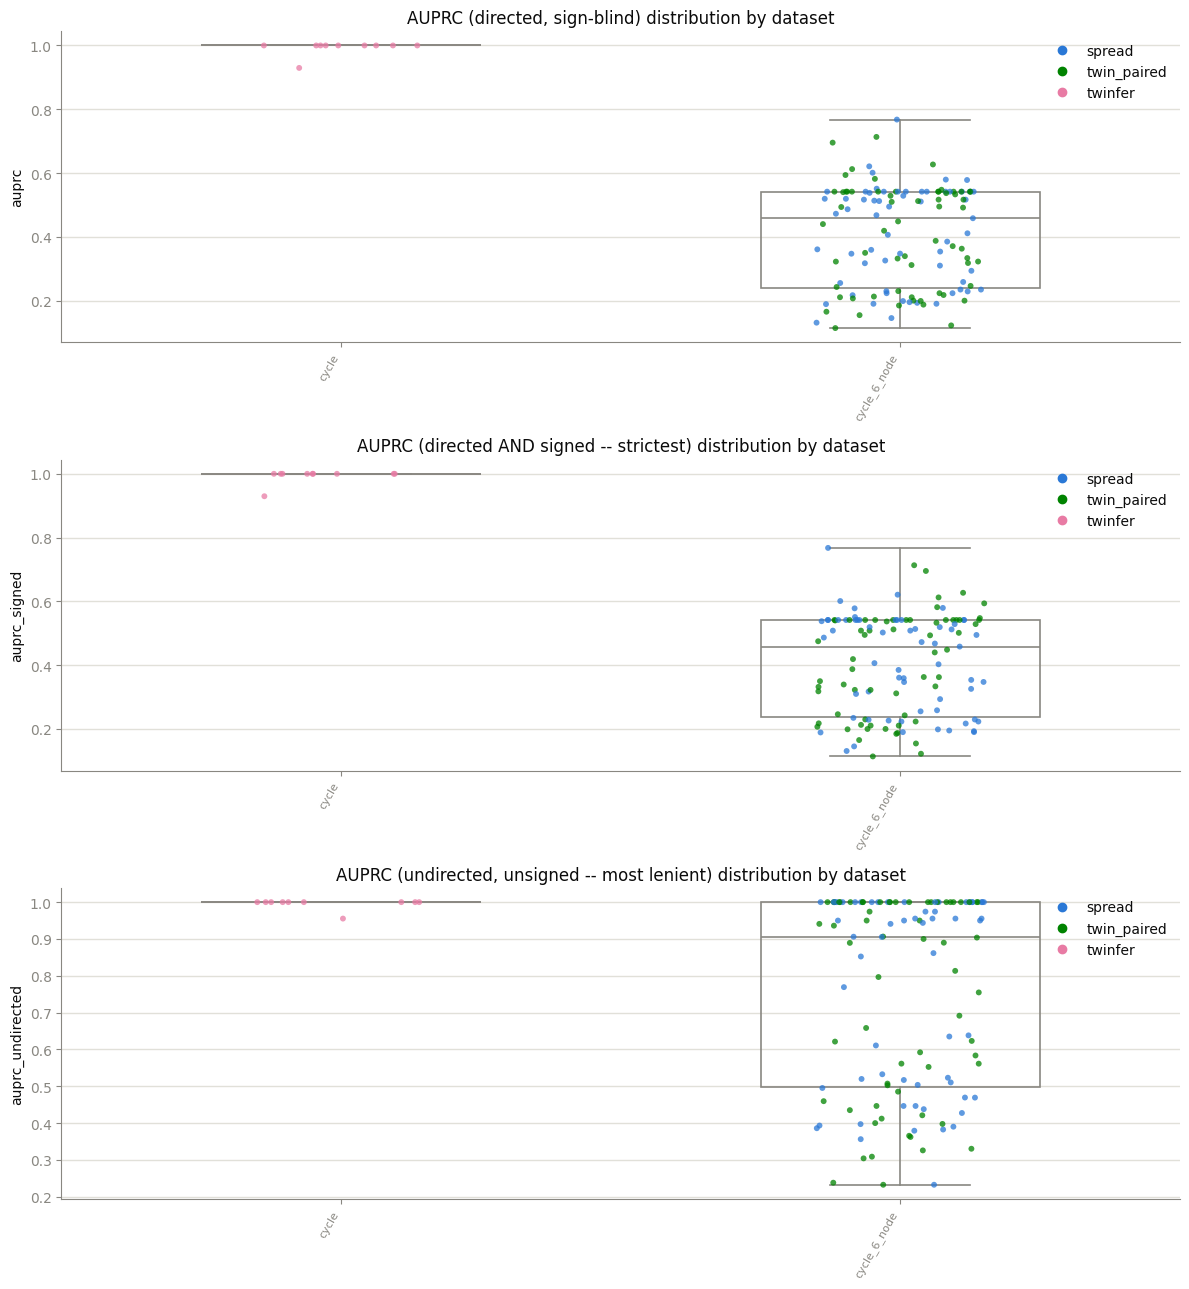

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 13))
plot_box_dot_by_dataset("auprc", ax=axes[0], title="AUPRC (directed, sign-blind) distribution by dataset")
plot_box_dot_by_dataset("auprc_signed", ax=axes[1], title="AUPRC (directed AND signed -- strictest) distribution by dataset")
plot_box_dot_by_dataset("auprc_undirected", ax=axes[2], title="AUPRC (undirected, unsigned -- most lenient) distribution by dataset")
fig.tight_layout()

## Heatmap: every method, identified

The box/dot plots above show the spread across algorithms per dataset, but don't identify *which* dot belongs to *which* algorithm. This heatmap makes algorithm identity an explicit axis: rows = algorithm, columns = dataset (averaged across sim_reps), color = metric value, one panel per scheme (small multiples, since scheme is a third dimension a single 2D heatmap can't also encode). Color here does a *magnitude* job, not an identity job, so it uses the single-hue sequential ramp (light -> dark blue) rather than the categorical palette used elsewhere in this notebook. Cell values are annotated directly since exact numbers matter for this kind of comparison.

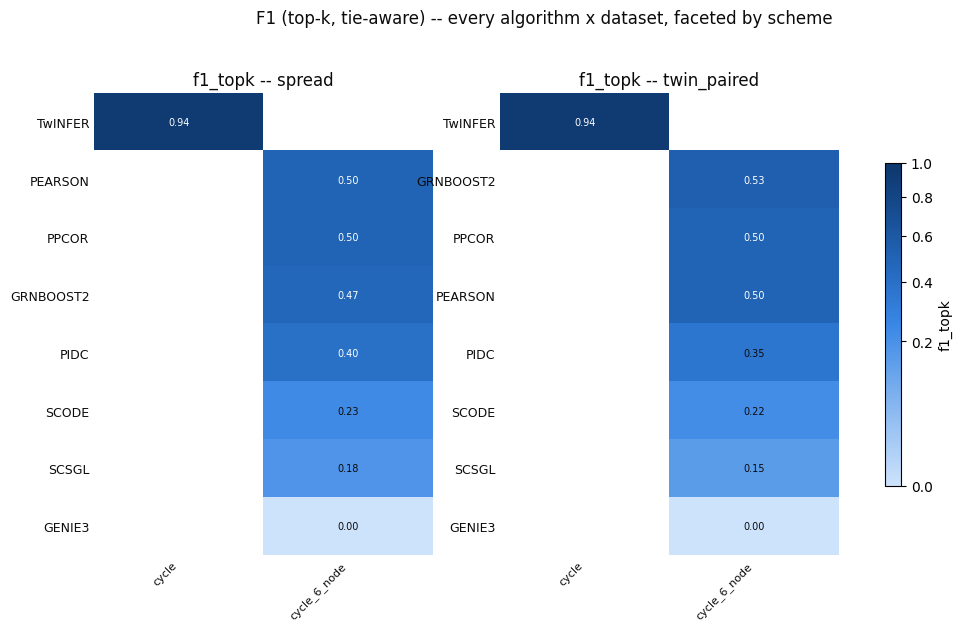

In [15]:
from matplotlib.colors import LinearSegmentedColormap, PowerNorm

# Validated sequential blue ramp (references/palette.md), light -> dark, for magnitude encoding
SEQUENTIAL_BLUE = LinearSegmentedColormap.from_list(
    "sequential_blue",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
)

# Gamma for the heatmaps' color normalization: these metrics rarely populate
# the low end of [0, 1] (values usually cluster well above zero), so a plain
# linear 0..vmax mapping crams almost all of the real data into a narrow,
# hard-to-distinguish band at the dark end of the ramp even though the scale
# is still anchored at true zero. gamma < 1 (PowerNorm) stretches that low-to
# -mid range back out across more of the visible spectrum while leaving 0
# fixed as the anchor and 1 as the ceiling -- same absolute scale, better
# perceptual spread for where the data actually live.
HEATMAP_GAMMA = 0.5

# Every dataset_id is "grn_n6_e{edges}_pos{pos}_{variant}_rep{rep}" -- n is
# fixed at 6 across the whole sweep, so it's dropped from the display label;
# pos is only informative for the sign_ratio variant (it's constant at 100
# for density/center), so it's only shown there.
DATASET_LABEL_RE = re.compile(
    r"^grn_n\d+_e(?P<e>\d+)(?:_pos(?P<pos>\d+))?_(?P<variant>density|sign_ratio|center)_rep(?P<rep>\d+)$"
)


def prettify_dataset_id(dataset_id: str) -> str:
    m = DATASET_LABEL_RE.match(dataset_id)
    if not m:
        return dataset_id
    pos_label = f"pos{m['pos']} " if m["variant"] == "sign_ratio" else ""
    return f"E{m['e']} {pos_label}{m['variant'].replace('_', ' ')} · r{m['rep']}"


def plot_heatmap_by_algorithm_dataset(metric: str, scheme: str, ax=None, title=None, norm=None):
    # TwINFER isn't run through either sampling scheme (it's its own method
    # operating on the raw twin-simulation data directly), so its row is the
    # same regardless of scheme -- fold it into every panel for direct
    # row-by-row comparison against the BEELINE algorithms instead of
    # segregating it into its own panel.
    subset = results[(results["scheme"] == scheme) | (results["algorithm"] == "TwINFER")]
    pivot = subset.groupby(["algorithm", "dataset_id"])[metric].mean().unstack("dataset_id")
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(0.6 * len(pivot.columns) + 3, 0.4 * len(pivot.index) + 2))

    # Anchored at true zero (norm.vmin == 0) by default so shading reflects
    # absolute magnitude, not the data's own floor -- see HEATMAP_GAMMA for
    # why the norm itself is nonlinear rather than plain vmin/vmax.
    if norm is None:
        vmax = float(pivot.values[~pd.isna(pivot.values)].max())
        norm = PowerNorm(gamma=HEATMAP_GAMMA, vmin=0.0, vmax=vmax)

    im = ax.imshow(pivot.values, cmap=SEQUENTIAL_BLUE, aspect="auto", norm=norm)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if pd.isna(val):
                continue
            # Flip label ink to white on the darkest cells so text stays
            # readable -- threshold on the normalized (post-gamma) value,
            # not the raw one, since that's what actually determines color.
            label_color = "#ffffff" if norm(val) > 0.6 else INK_PRIMARY
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=label_color)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([prettify_dataset_id(c) for c in pivot.columns], rotation=45, ha="right",
                        color=INK_PRIMARY, fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, color=INK_PRIMARY, fontsize=9)
    ax.set_title(title or f"{metric} -- {scheme}", color=INK_PRIMARY)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

    if own_ax:
        fig.colorbar(im, ax=ax, shrink=0.8, label=metric)
        fig.tight_layout()
        return fig
    return im


def plot_heatmap_panels(metric: str, suptitle: str = None):
    """One heatmap panel per real sampling scheme (spread, twin_paired), TwINFER folded into both."""
    schemes = [s for s in ["spread", "twin_paired"] if s in results["scheme"].unique()]
    fig, axes = plt.subplots(1, len(schemes), figsize=(6 * len(schemes), 6))
    if len(schemes) == 1:
        axes = [axes]

    # Anchored at true zero (this metric is bounded [0, 1]), with the ramp's
    # gamma stretch (HEATMAP_GAMMA) shared across every panel here so cell
    # colors stay comparable panel-to-panel -- ceiling the observed max to
    # the nearest 0.1 for a clean, still-legible top.
    vmax = float(np.clip(np.ceil(results[metric].max() * 10) / 10, 0.1, 1.0))
    norm = PowerNorm(gamma=HEATMAP_GAMMA, vmin=0.0, vmax=vmax)
    ims = [plot_heatmap_by_algorithm_dataset(metric, s, ax=ax, norm=norm)
           for ax, s in zip(axes, schemes)]

    fig.colorbar(ims[-1], ax=axes, shrink=0.7, label=metric, location="right")
    fig.suptitle(suptitle or f"{metric} -- every algorithm x dataset, faceted by scheme", color=INK_PRIMARY, y=1.02)
    return fig


plot_heatmap_panels("f1_topk", "F1 (top-k, tie-aware) -- every algorithm x dataset, faceted by scheme");

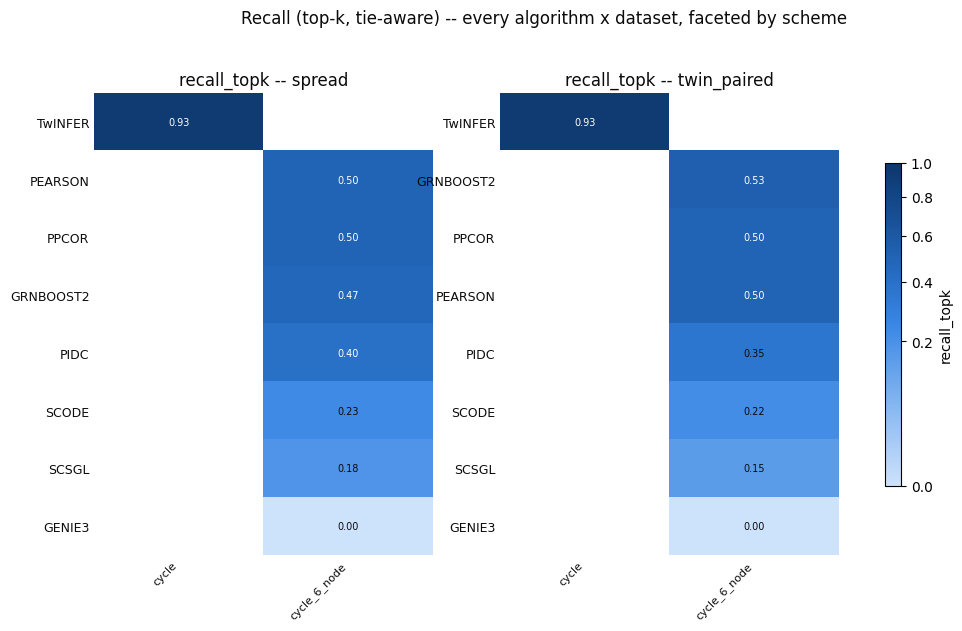

In [16]:
plot_heatmap_panels("recall_topk", "Recall (top-k, tie-aware) -- every algorithm x dataset, faceted by scheme");

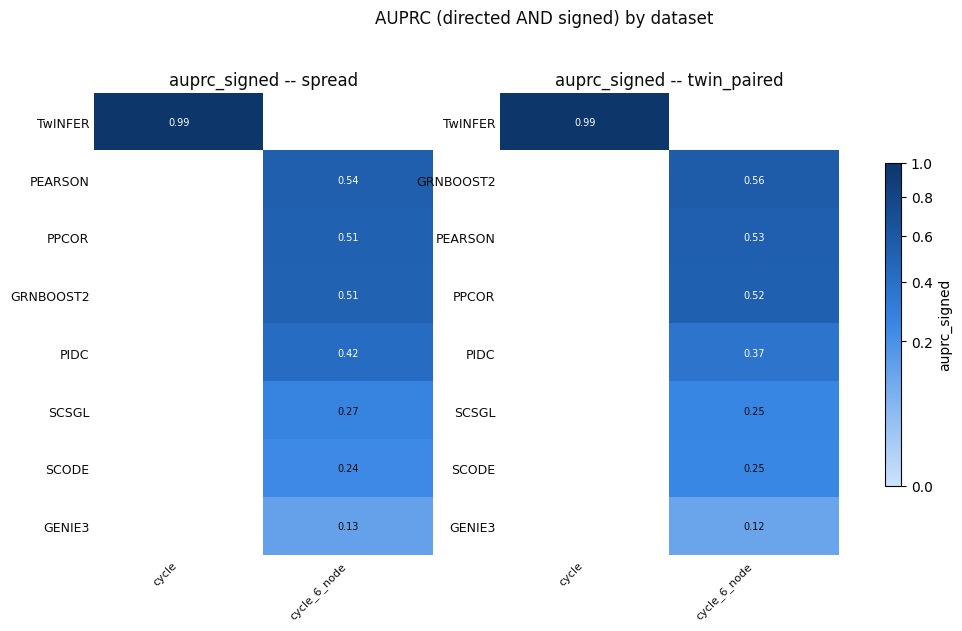

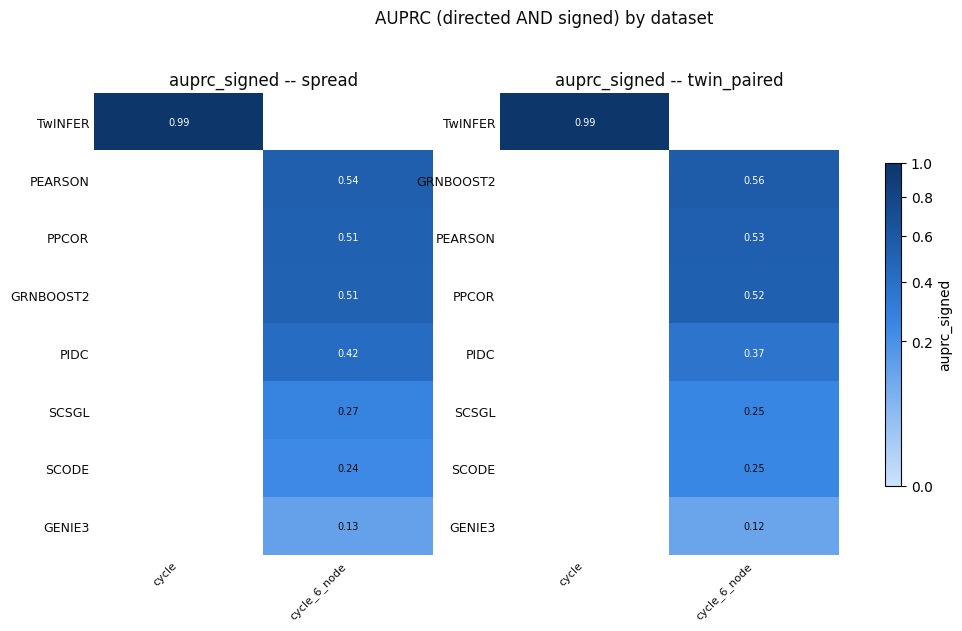

In [17]:
plot_heatmap_panels("auprc_signed", "AUPRC (directed AND signed) by dataset")

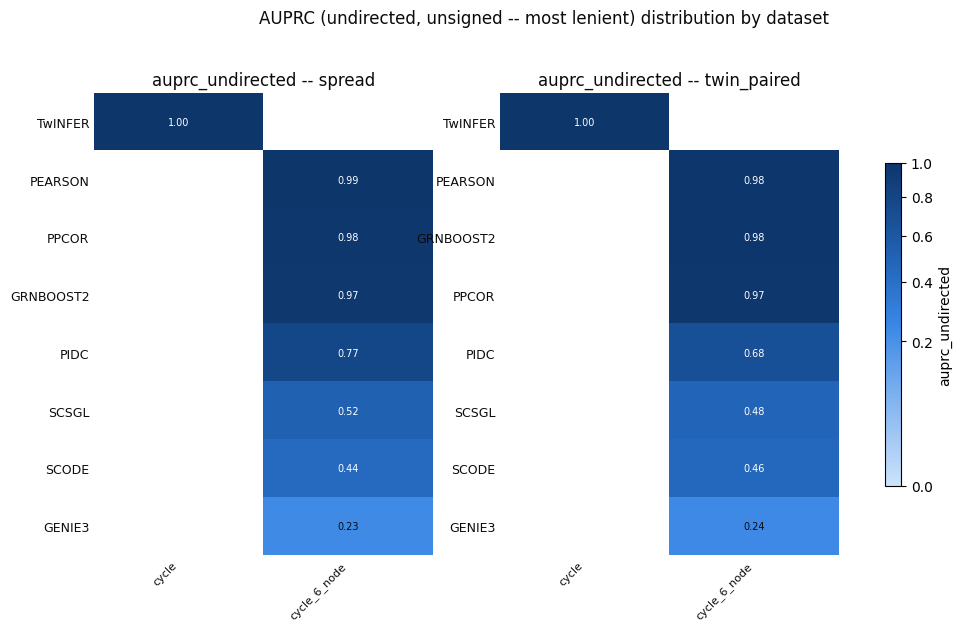

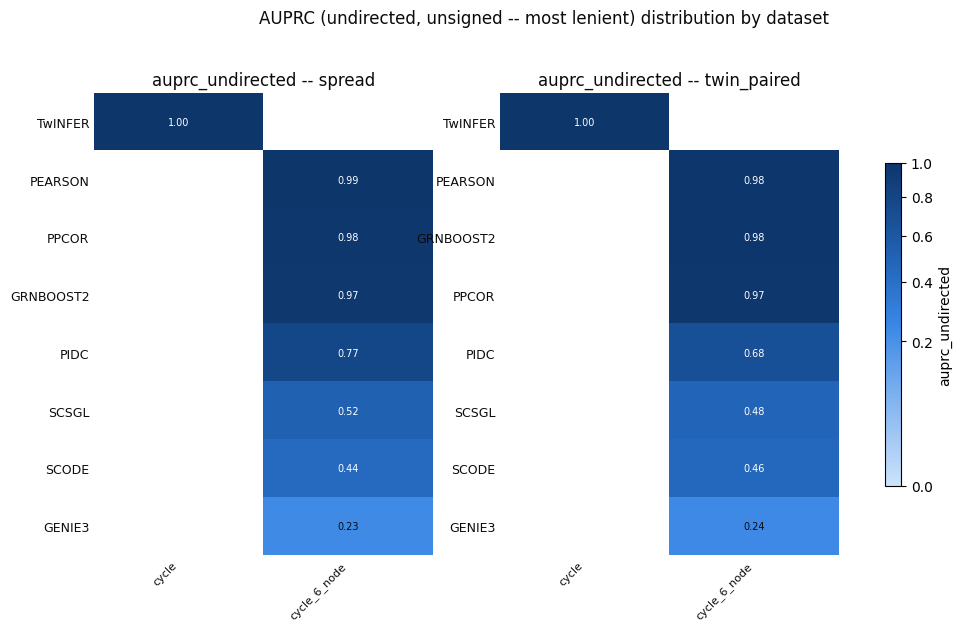

In [18]:
plot_heatmap_panels("auprc_undirected", "AUPRC (undirected, unsigned -- most lenient) distribution by dataset")


## Notes

- **EPR** (Early Precision Ratio) is `precision_topk / random_baseline_precision` -- values above 1 mean better than random chance for that dataset's edge density; included since it's directly comparable to BEELINE's own published numbers.
- Compare `n_selected_natural` to `n_true_edges` per algorithm in the summary table above: if they're close, `f1_topk` and `f1_natural` should roughly agree; a big gap between the two F1 columns for a given algorithm is the signal that it's the "outputs its own fixed network" type, and `f1_natural` is the fairer number to cite for it.
- Algorithms with `should_run: [False]` in the config (e.g. LEAP, SINCERITIES against `twin_paired`) simply won't have `rankedEdges.csv` files and are silently absent from these tables rather than erroring.
- If `BLRunner.py`'s per-runner error handling caused some (dataset, run, algorithm) combination to fail outright, it also won't appear here -- cross-check against the "N of M run(s) failed" summary `BLRunner.py` prints at the end of a benchmark pass.
- **`_signed` and `_undirected` columns**: three strictness levels are now computed side by side for every algorithm -- the original columns (directed, sign-blind), `_signed` (directed AND signed -- any mismatch is incorrect, the strictest), and `_undirected` (existence only, ignoring both direction and sign -- the most lenient). Expect `precision_undirected >= precision >= precision_signed` for a given algorithm/threshold, since each step only relaxes what counts as a match. For TwINFER, all three `auprc*` columns are real (computed from `ranked_edge_list` in `network_sweep_analysis.ipynb`); the threshold-based `precision_topk_signed`/`recall_topk_signed`/etc. columns are still `NaN` there (see the markdown cell above "Two additional comparison strictness levels").